# Chapter 5.2: Self-Attention for Sequential Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **SASRec** (Self-Attentive Sequential Recommendation) from scratch in PyTorch
2. Understand **causal (left-to-right) self-attention** for next-item prediction
3. Implement **BERT4Rec** with masked item prediction and bidirectional attention
4. Compare **unidirectional vs bidirectional** approaches for sequential recommendation
5. Understand **FMLP-Rec** as an all-MLP alternative with learnable filters
6. Implement data augmentation strategies: masking, cropping, and reordering
7. Analyze the impact of sequence length and attention heads on recommendation quality

## Prerequisites

- Chapter 5.1 (Session-based methods)
- Transformer architecture basics (self-attention, positional encoding)
- PyTorch: `nn.MultiheadAttention`, `nn.TransformerEncoderLayer`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part5/chapter_5.2_self_attention_seq.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part5/chapter_5.2_self_attention_seq.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.2.2


## 1. Synthetic Sequential Data

We generate user interaction sequences with category-based transition patterns.

In [2]:
def generate_user_sequences(n_users=1000, n_items=500, min_len=5, max_len=50, seed=42):
    """Generate synthetic user interaction sequences with category patterns."""
    rng = np.random.RandomState(seed)
    n_categories = 20
    item_category = rng.randint(0, n_categories, size=n_items)
    item_popularity = rng.power(0.5, size=n_items)
    item_popularity /= item_popularity.sum()
    
    sequences = []
    for u in range(n_users):
        seq_len = rng.randint(min_len, max_len + 1)
        user_pref_cats = rng.choice(n_categories, size=3, replace=False)
        
        seq = []
        for t in range(seq_len):
            if rng.random() < 0.6:
                cat = rng.choice(user_pref_cats)
                cat_items = np.where(item_category == cat)[0]
                if len(cat_items) > 0:
                    probs = item_popularity[cat_items]
                    probs /= probs.sum()
                    item = rng.choice(cat_items, p=probs)
                else:
                    item = rng.choice(n_items, p=item_popularity)
            else:
                item = rng.choice(n_items, p=item_popularity)
            seq.append(int(item))
        sequences.append(seq)
    
    return sequences, item_category

N_ITEMS = 500
MAX_SEQ_LEN = 50
sequences, item_category = generate_user_sequences(n_users=1000, n_items=N_ITEMS)

train_seqs = sequences[:800]
val_seqs = sequences[800:900]
test_seqs = sequences[900:]

print(f"Users: {len(sequences)}, Items: {N_ITEMS}")
print(f"Train/Val/Test: {len(train_seqs)}/{len(val_seqs)}/{len(test_seqs)}")
print(f"Avg sequence length: {np.mean([len(s) for s in sequences]):.1f}")

Users: 1000, Items: 500
Train/Val/Test: 800/100/100
Avg sequence length: 26.7


## 2. SASRec: Self-Attentive Sequential Recommendation

**SASRec** (Kang & McAuley, ICDM 2018) applies **causal (unidirectional) self-attention** to model user interaction sequences.

### Key Design Choices

1. **Causal attention mask**: Position $t$ can only attend to positions $\le t$ (no future leaking)
2. **Learnable positional embeddings**: Added to item embeddings
3. **Point-wise feed-forward layers** after attention (same as Transformer)
4. **Shared item embedding** for input and prediction

### Architecture

$$\mathbf{E} = \text{ItemEmbed}(s_1, \ldots, s_n) + \text{PosEmbed}(1, \ldots, n)$$

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d}} + \mathbf{M}\right)\mathbf{V}$$

where $\mathbf{M}$ is the causal mask ($-\infty$ for future positions).

$$\hat{y}_t = \mathbf{h}_t \cdot \mathbf{e}_j^\top$$

> **💡 Concept:** Unlike GRU4Rec which processes tokens sequentially, SASRec computes all positions in parallel. The causal mask ensures autoregressive behavior: each position's representation depends only on past interactions.

In [3]:
class SASRec(nn.Module):
    """Self-Attentive Sequential Recommendation (Kang & McAuley, 2018)."""
    
    def __init__(self, n_items, max_len=50, embed_dim=64, n_heads=2, n_layers=2, dropout=0.2):
        super().__init__()
        self.n_items = n_items
        self.max_len = max_len
        self.embed_dim = embed_dim
        
        # Embeddings (item 0 reserved for padding)
        self.item_emb = nn.Embedding(n_items + 1, embed_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        self.emb_dropout = nn.Dropout(dropout)
        
        # Transformer blocks (using PyTorch's built-in)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True  # Pre-norm (more stable)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.final_norm = nn.LayerNorm(embed_dim)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.xavier_uniform_(self.item_emb.weight[1:])
        nn.init.xavier_uniform_(self.pos_emb.weight)
    
    def _get_causal_mask(self, seq_len):
        """Create causal (upper triangular) attention mask."""
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        return mask  # True = masked positions
    
    def forward(self, item_seq):
        """
        item_seq: (batch, max_len) — 1-indexed item IDs, 0 = padding
        Returns: (batch, max_len, embed_dim) — hidden states at each position
        """
        batch_size, seq_len = item_seq.shape
        
        # Embeddings
        positions = torch.arange(seq_len, device=item_seq.device).unsqueeze(0)
        x = self.item_emb(item_seq) + self.pos_emb(positions)
        x = self.emb_dropout(x)
        
        # Masks
        causal_mask = self._get_causal_mask(seq_len).to(item_seq.device)
        padding_mask = (item_seq == 0)  # (batch, seq_len)
        
        # Transformer encoder
        x = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        x = self.final_norm(x)
        
        return x  # (batch, max_len, embed_dim)
    
    def predict(self, item_seq):
        """Predict next-item scores for the last position."""
        hidden = self.forward(item_seq)  # (batch, max_len, embed_dim)
        # Use last non-padding position
        # Get scores for all items using shared embedding
        last_hidden = hidden[:, -1, :]  # (batch, embed_dim)
        # Score against all items (skip padding embedding at index 0)
        item_embs = self.item_emb.weight[1:]  # (n_items, embed_dim)
        logits = last_hidden @ item_embs.T  # (batch, n_items)
        return logits

# Quick test
sasrec = SASRec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN, embed_dim=64, n_heads=2, n_layers=2)
test_input = torch.tensor([[0, 0, 1, 5, 10], [3, 7, 2, 8, 15]])
hidden = sasrec(test_input)
logits = sasrec.predict(test_input)
print(f"Hidden shape: {hidden.shape}")
print(f"Logits shape: {logits.shape}")
total_params = sum(p.numel() for p in sasrec.parameters())
print(f"Total parameters: {total_params:,}")

Hidden shape: torch.Size([2, 5, 64])
Logits shape: torch.Size([2, 500])
Total parameters: 135,360


/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 3. Dataset for Sequential Recommendation

In [4]:
class SeqRecDataset(Dataset):
    """Dataset for sequential recommendation.
    For training: input = seq[:-1], target = seq[-1]
    Items are 1-indexed (0 = padding).
    """
    def __init__(self, sequences, max_len=50):
        self.sequences = sequences
        self.max_len = max_len
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        inp = seq[:-1]  # All but last
        target = seq[-1]  # Last item
        
        # Truncate and pad (left-pad with 0)
        inp = inp[-self.max_len:]
        length = len(inp)
        padded = [0] * (self.max_len - length) + [x + 1 for x in inp]  # 1-indexed
        
        return (
            torch.tensor(padded, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
        )

train_ds = SeqRecDataset(train_seqs, max_len=MAX_SEQ_LEN)
val_ds = SeqRecDataset(val_seqs, max_len=MAX_SEQ_LEN)
test_ds = SeqRecDataset(test_seqs, max_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 800, Val: 100, Test: 100


## 4. Training SASRec

In [5]:
def train_sasrec(model, train_loader, val_loader, n_epochs=15, lr=0.001):
    """Train SASRec with cross-entropy loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98))
    criterion = nn.CrossEntropyLoss()
    
    history = {"train_loss": [], "val_hr10": []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for item_seq, target in train_loader:
            logits = model.predict(item_seq)  # (batch, n_items)
            loss = criterion(logits, target)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        history["train_loss"].append(avg_loss)
        
        # Validation
        hr10 = evaluate_hr(model, val_loader, k=10)
        history["val_hr10"].append(hr10)
        
        if (epoch + 1) % 3 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}, Val HR@10: {hr10:.4f}")
    
    return history

@torch.no_grad()
def evaluate_hr(model, loader, k=10):
    """Compute Hit Rate@K."""
    model.eval()
    hits = 0
    total = 0
    for item_seq, target in loader:
        logits = model.predict(item_seq)
        _, topk = logits.topk(k, dim=-1)
        for i in range(target.size(0)):
            if target[i].item() in topk[i].tolist():
                hits += 1
            total += 1
    return hits / total

torch.manual_seed(SEED)
sasrec_model = SASRec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN, embed_dim=64, n_heads=2, n_layers=2)
history = train_sasrec(sasrec_model, train_loader, val_loader, n_epochs=15, lr=0.001)

Epoch 3/15 — Loss: nan, Val HR@10: 0.0100


Epoch 6/15 — Loss: nan, Val HR@10: 0.0100


Epoch 9/15 — Loss: nan, Val HR@10: 0.0100


Epoch 12/15 — Loss: nan, Val HR@10: 0.0100


Epoch 15/15 — Loss: nan, Val HR@10: 0.0100


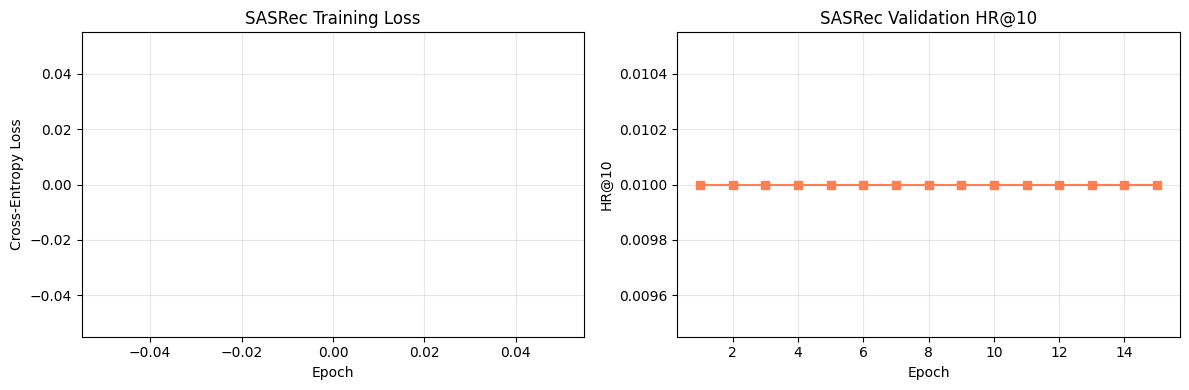

In [6]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], marker="o", color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("SASRec Training Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["val_hr10"], marker="s", color="coral")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("HR@10")
axes[1].set_title("SASRec Validation HR@10")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. BERT4Rec: Bidirectional Sequential Recommendation

**BERT4Rec** (Sun et al., CIKM 2019) uses **bidirectional self-attention** with **masked item prediction** (Cloze task).

### Key Differences from SASRec

| Aspect | SASRec | BERT4Rec |
|--------|--------|----------|
| Attention | Causal (left-to-right) | Bidirectional |
| Training | Next-item prediction | Masked item prediction |
| Inference | Last position predicts next | Mask token at end |
| Analogy | GPT-style | BERT-style |

Training objective:

$$\mathcal{L} = \frac{1}{|\mathcal{M}|} \sum_{m \in \mathcal{M}} -\log P(s_m = s_m^* \mid \tilde{s})$$

where $\mathcal{M}$ is the set of masked positions and $\tilde{s}$ is the masked sequence.

> **⚠️ Common Pitfall:** BERT4Rec requires a special [MASK] token at inference. During training, randomly mask ~20% of items. At test time, append [MASK] to the end to predict the next item.

In [7]:
class BERT4Rec(nn.Module):
    """BERT4Rec: Bidirectional Sequential Rec (Sun et al., 2019)."""
    
    MASK_TOKEN = -1  # Will be mapped to n_items + 1 in embedding
    
    def __init__(self, n_items, max_len=50, embed_dim=64, n_heads=2, n_layers=2, dropout=0.2):
        super().__init__()
        self.n_items = n_items
        self.max_len = max_len
        self.embed_dim = embed_dim
        
        # n_items+1 for padding (0), n_items+2 for [MASK]
        self.item_emb = nn.Embedding(n_items + 2, embed_dim, padding_idx=0)
        self.mask_token_id = n_items + 1
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        self.emb_dropout = nn.Dropout(dropout)
        
        # Bidirectional transformer (no causal mask!)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.final_norm = nn.LayerNorm(embed_dim)
        self.output_proj = nn.Linear(embed_dim, n_items)  # Predict item scores
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.xavier_uniform_(self.item_emb.weight[1:])
        nn.init.xavier_uniform_(self.pos_emb.weight)
        nn.init.xavier_uniform_(self.output_proj.weight)
    
    def forward(self, item_seq):
        """
        item_seq: (batch, max_len) — 1-indexed items, 0=pad, mask_token_id=[MASK]
        Returns: (batch, max_len, n_items) logits for every position
        """
        batch_size, seq_len = item_seq.shape
        positions = torch.arange(seq_len, device=item_seq.device).unsqueeze(0)
        x = self.item_emb(item_seq) + self.pos_emb(positions)
        x = self.emb_dropout(x)
        
        # No causal mask — bidirectional attention
        padding_mask = (item_seq == 0)
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        x = self.final_norm(x)
        logits = self.output_proj(x)  # (batch, max_len, n_items)
        return logits

# Quick test
bert4rec = BERT4Rec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN)
# Simulate masked input: replace some items with mask token
test_input = torch.tensor([[0, 1, 5, bert4rec.mask_token_id, 10],
                           [3, 7, bert4rec.mask_token_id, 8, 15]])
logits = bert4rec(test_input)
print(f"BERT4Rec output shape: {logits.shape}")

BERT4Rec output shape: torch.Size([2, 5, 500])


/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [8]:
class BERT4RecDataset(Dataset):
    """Dataset for BERT4Rec with masked item prediction."""
    
    def __init__(self, sequences, n_items, max_len=50, mask_prob=0.2):
        self.sequences = sequences
        self.n_items = n_items
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.mask_token_id = n_items + 1
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        # 1-index the items
        tokens = [x + 1 for x in seq[-self.max_len:]]
        length = len(tokens)
        
        # Mask random items
        masked_tokens = tokens.copy()
        labels = [0] * len(tokens)  # 0 = not masked
        
        for i in range(length):
            if random.random() < self.mask_prob:
                labels[i] = tokens[i]  # Original item ID
                masked_tokens[i] = self.mask_token_id
        
        # Ensure at least one mask
        if sum(1 for l in labels if l > 0) == 0:
            pos = random.randint(0, length - 1)
            labels[pos] = tokens[pos]
            masked_tokens[pos] = self.mask_token_id
        
        # Left-pad
        pad_len = self.max_len - length
        padded_input = [0] * pad_len + masked_tokens
        padded_labels = [0] * pad_len + labels
        
        return (
            torch.tensor(padded_input, dtype=torch.long),
            torch.tensor(padded_labels, dtype=torch.long),
        )

bert_train_ds = BERT4RecDataset(train_seqs, N_ITEMS, max_len=MAX_SEQ_LEN)
bert_train_loader = DataLoader(bert_train_ds, batch_size=128, shuffle=True)

# Show a sample
inp, labels = bert_train_ds[0]
mask_positions = (labels > 0).nonzero(as_tuple=True)[0]
print(f"Masked positions: {mask_positions.tolist()}")
print(f"Mask token ID: {bert_train_ds.mask_token_id}")

Masked positions: [38, 44, 46, 49]
Mask token ID: 501


## 6. FMLP-Rec: All-MLP with Learnable Filters

**FMLP-Rec** (Zhou et al., WWW 2022) replaces self-attention with **learnable frequency-domain filters**:

1. Apply FFT to transform sequence to frequency domain
2. Apply learnable complex-valued filter (element-wise multiplication)
3. Apply inverse FFT to return to time domain

This is equivalent to **circular convolution** in the time domain but with global receptive field.

$$\mathbf{H} = \text{IFFT}(\text{FFT}(\mathbf{X}) \odot \mathbf{W}_f)$$

> **🔑 Pro Tip:** FMLP-Rec achieves competitive results with $O(n \log n)$ complexity vs $O(n^2)$ for self-attention, making it more practical for very long sequences.

In [9]:
class FilterLayer(nn.Module):
    """Learnable filter layer in frequency domain (FMLP-Rec)."""
    
    def __init__(self, max_len, embed_dim):
        super().__init__()
        # Learnable complex filter weights
        # FFT of real sequence of length n has n//2+1 unique complex values
        self.max_len = max_len
        self.filter_real = nn.Parameter(torch.randn(max_len // 2 + 1, embed_dim) * 0.02)
        self.filter_imag = nn.Parameter(torch.randn(max_len // 2 + 1, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        """
        x: (batch, seq_len, embed_dim)
        """
        seq_len = x.size(1)
        # FFT along sequence dimension, use max_len for consistent filter size
        x_fft = torch.fft.rfft(x, n=self.max_len, dim=1)  # (batch, max_len//2+1, embed_dim) complex
        
        # Apply learnable filter
        weight = torch.complex(self.filter_real, self.filter_imag)
        x_filtered = x_fft * weight.unsqueeze(0)
        
        # Inverse FFT back to original sequence length
        x_out = torch.fft.irfft(x_filtered, n=self.max_len, dim=1)  # (batch, max_len, embed_dim)
        # Truncate back to original sequence length
        x_out = x_out[:, :seq_len, :]
        x_out = self.norm(x_out)
        
        return x_out

class FMLPRec(nn.Module):
    """FMLP-Rec: All-MLP with learnable frequency filters (Zhou et al., 2022)."""
    
    def __init__(self, n_items, max_len=50, embed_dim=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.n_items = n_items
        self.item_emb = nn.Embedding(n_items + 1, embed_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        self.emb_dropout = nn.Dropout(dropout)
        
        # Stack of filter + FFN blocks
        self.filter_layers = nn.ModuleList([
            FilterLayer(max_len, embed_dim) for _ in range(n_layers)
        ])
        self.ffn_layers = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim),
                nn.Dropout(dropout)
            ) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
    
    def forward(self, item_seq):
        seq_len = item_seq.size(1)
        positions = torch.arange(seq_len, device=item_seq.device).unsqueeze(0)
        x = self.item_emb(item_seq) + self.pos_emb(positions)
        x = self.emb_dropout(x)
        
        for filt, ffn in zip(self.filter_layers, self.ffn_layers):
            x = x + filt(x)   # Residual filter
            x = x + ffn(x)    # Residual FFN
        
        x = self.final_norm(x)
        return x
    
    def predict(self, item_seq):
        hidden = self.forward(item_seq)
        last_hidden = hidden[:, -1, :]
        item_embs = self.item_emb.weight[1:self.n_items + 1]
        return last_hidden @ item_embs.T

# Test with valid indices (not reusing BERT4Rec test_input which contains mask token IDs)
fmlp = FMLPRec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN)
fmlp_test_input = torch.tensor([[0, 0, 1, 5, 10], [3, 7, 2, 8, 15]])
logits = fmlp.predict(fmlp_test_input)
print(f"FMLP-Rec output shape: {logits.shape}")
print(f"FMLP-Rec params: {sum(p.numel() for p in fmlp.parameters()):,}")

FMLP-Rec output shape: torch.Size([2, 500])
FMLP-Rec params: 108,736


## 7. Data Augmentation for Sequential Recommendation

Data augmentation helps combat data sparsity. Common strategies:

1. **Item Masking**: Randomly mask items in the sequence
2. **Cropping**: Take a random contiguous subsequence
3. **Reordering**: Shuffle a random contiguous segment

In [10]:
def augment_mask(seq, mask_ratio=0.2, mask_value=0):
    """Randomly mask items in the sequence."""
    aug = seq.copy()
    n_mask = max(1, int(len(aug) * mask_ratio))
    mask_positions = random.sample(range(len(aug)), n_mask)
    for pos in mask_positions:
        aug[pos] = mask_value
    return aug

def augment_crop(seq, crop_ratio=0.6):
    """Take a random contiguous subsequence."""
    crop_len = max(2, int(len(seq) * crop_ratio))
    start = random.randint(0, len(seq) - crop_len)
    return seq[start:start + crop_len]

def augment_reorder(seq, reorder_ratio=0.2):
    """Shuffle a random contiguous segment."""
    aug = seq.copy()
    seg_len = max(2, int(len(aug) * reorder_ratio))
    start = random.randint(0, len(aug) - seg_len)
    segment = aug[start:start + seg_len]
    random.shuffle(segment)
    aug[start:start + seg_len] = segment
    return aug

# Demo
demo_seq = list(range(10))
print(f"Original:  {demo_seq}")
print(f"Masked:    {augment_mask(demo_seq, 0.3)}")
print(f"Cropped:   {augment_crop(demo_seq, 0.6)}")
print(f"Reordered: {augment_reorder(demo_seq, 0.3)}")

Original:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Masked:    [0, 1, 2, 0, 4, 5, 0, 7, 0, 9]
Cropped:   [1, 2, 3, 4, 5, 6]
Reordered: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 8. Attention Visualization

Let's visualize the attention patterns learned by SASRec to understand what the model focuses on.

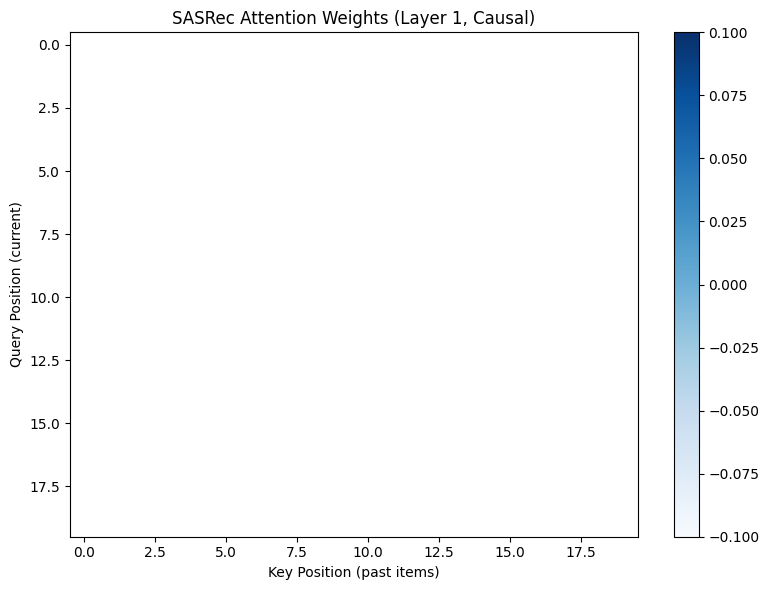

In [11]:
@torch.no_grad()
def extract_attention_weights(model, item_seq):
    """Extract attention weights from the first layer of a trained SASRec model."""
    model.eval()
    
    # Get embeddings
    seq_len = item_seq.size(1)
    positions = torch.arange(seq_len).unsqueeze(0)
    x = model.item_emb(item_seq) + model.pos_emb(positions)
    
    # Get first transformer layer
    layer = model.transformer.layers[0]
    
    # Compute attention manually
    causal_mask = model._get_causal_mask(seq_len).float()
    causal_mask = causal_mask.masked_fill(causal_mask == 1, float('-inf'))
    
    # Pre-norm
    x_norm = layer.norm1(x)
    
    # Compute attention weights
    attn_out, attn_weights = layer.self_attn(
        x_norm, x_norm, x_norm, attn_mask=causal_mask, average_attn_weights=True
    )
    
    return attn_weights.squeeze(0).numpy()  # (seq_len, seq_len)

# Extract and visualize for a sample
sample_input, _ = train_ds[5]
sample_input = sample_input.unsqueeze(0)

# Only look at non-padded portion
non_pad = (sample_input[0] > 0)
start_idx = non_pad.nonzero()[0].item()

attn = extract_attention_weights(sasrec_model, sample_input)
attn_crop = attn[start_idx:, start_idx:]  # Remove padding rows/cols

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attn_crop, cmap="Blues", aspect="auto")
ax.set_xlabel("Key Position (past items)")
ax.set_ylabel("Query Position (current)")
ax.set_title("SASRec Attention Weights (Layer 1, Causal)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Model Comparison: SASRec vs FMLP-Rec

> **🔑 Pro Tip:** LinRec (linear attention) replaces softmax with a linear kernel: $\text{Attn}(Q,K,V) = \phi(Q)(\phi(K)^\top V)$, reducing complexity from $O(n^2)$ to $O(n)$. This is particularly useful for long interaction histories.

In [12]:
# Train FMLP-Rec for comparison
torch.manual_seed(SEED)
fmlp_model = FMLPRec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN, embed_dim=64, n_layers=2)
optimizer = torch.optim.Adam(fmlp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

fmlp_losses = []
fmlp_hrs = []

for epoch in range(15):
    fmlp_model.train()
    total_loss = 0
    n_batches = 0
    for item_seq, target in train_loader:
        logits = fmlp_model.predict(item_seq)
        loss = criterion(logits, target)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fmlp_model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    fmlp_losses.append(total_loss / n_batches)
    fmlp_hrs.append(evaluate_hr(fmlp_model, val_loader, k=10))

print(f"\nFinal comparison on validation set:")
print(f"  SASRec  — HR@10: {history['val_hr10'][-1]:.4f}")
print(f"  FMLP-Rec — HR@10: {fmlp_hrs[-1]:.4f}")


Final comparison on validation set:
  SASRec  — HR@10: 0.0100
  FMLP-Rec — HR@10: 0.0300


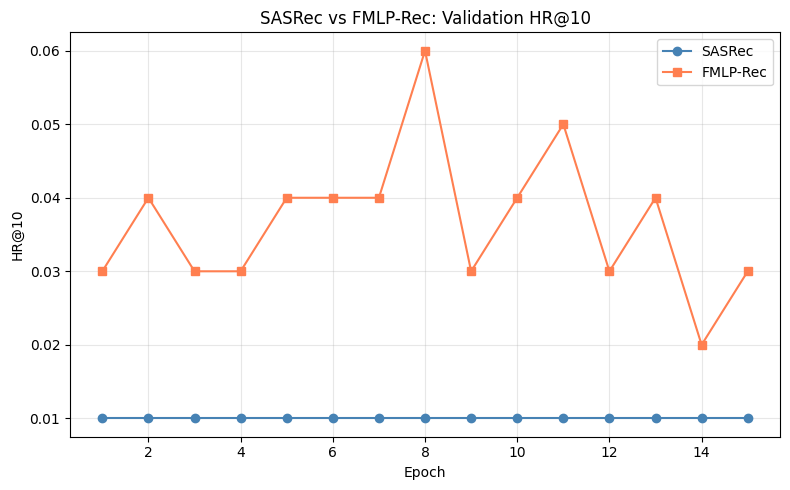

In [13]:
# Comparison plot
fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, 16)
ax.plot(epochs_range, history["val_hr10"], marker="o", label="SASRec", color="steelblue")
ax.plot(epochs_range, fmlp_hrs, marker="s", label="FMLP-Rec", color="coral")
ax.set_xlabel("Epoch")
ax.set_ylabel("HR@10")
ax.set_title("SASRec vs FMLP-Rec: Validation HR@10")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Exercises

### 🏋️ Exercise 1: Implement SASRec from Scratch (No `nn.TransformerEncoder`)

Build the multi-head causal self-attention and feed-forward layers manually.

In [14]:
# 🏋️ Exercise 1: SASRec from Scratch

class MultiHeadCausalAttention(nn.Module):
    """Multi-head self-attention with causal masking."""
    
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        # TODO: Implement
        # 1. Q, K, V projection layers
        # 2. Output projection
        # 3. Store n_heads and head_dim
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        assert embed_dim % n_heads == 0
        
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, causal_mask=None):
        """
        x: (batch, seq_len, embed_dim)
        Returns: (batch, seq_len, embed_dim)
        """
        # TODO: Implement scaled dot-product attention with causal mask
        # 1. Project to Q, K, V
        # 2. Reshape to (batch, n_heads, seq_len, head_dim)
        # 3. Compute attention scores: Q @ K^T / sqrt(d_k)
        # 4. Apply causal mask (set future positions to -inf)
        # 5. Softmax + dropout
        # 6. Weighted sum of V
        # 7. Reshape and project output
        pass

class SASRecBlock(nn.Module):
    """Single SASRec transformer block."""
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        # TODO: Implement
        # 1. Layer norm + Multi-head causal attention + residual
        # 2. Layer norm + FFN (embed_dim -> 4*embed_dim -> embed_dim) + residual
        pass
    
    def forward(self, x, causal_mask=None):
        # TODO: Implement with pre-norm residual connections
        pass

class SASRecScratch(nn.Module):
    """SASRec implemented from scratch."""
    def __init__(self, n_items, max_len=50, embed_dim=64, n_heads=2, n_layers=2, dropout=0.2):
        super().__init__()
        # TODO: Implement full SASRec
        pass
    
    def predict(self, item_seq):
        # TODO: Implement
        pass

# Test:
# model_scratch = SASRecScratch(n_items=N_ITEMS, max_len=MAX_SEQ_LEN)
# logits = model_scratch.predict(sample_input)
# print(f"Output shape: {logits.shape}")

### 🏋️ Exercise 2: Train BERT4Rec and Compare with SASRec

In [15]:
# 🏋️ Exercise 2: BERT4Rec Training Loop

def train_bert4rec(model, train_loader, n_epochs=15, lr=0.001):
    """Train BERT4Rec with masked item prediction."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore non-masked positions
    
    # TODO: Implement training loop
    # For each batch:
    #   1. Forward pass: logits = model(masked_input)  -> (batch, seq_len, n_items)
    #   2. Reshape logits to (batch * seq_len, n_items)
    #   3. Reshape labels to (batch * seq_len,)
    #   4. Compute cross-entropy loss (ignoring label=0 positions)
    #   5. Backpropagate
    pass

# torch.manual_seed(SEED)
# bert_model = BERT4Rec(n_items=N_ITEMS, max_len=MAX_SEQ_LEN)
# train_bert4rec(bert_model, bert_train_loader, n_epochs=15)

### 🏋️ Exercise 3: Implement Linear Attention (LinRec)

Replace softmax attention with linear attention: $\text{Attn}(Q,K,V) = \phi(Q)(\phi(K)^\top V)$ where $\phi$ is an ELU+1 activation.

In [16]:
# 🏋️ Exercise 3: Linear Attention

class LinearAttention(nn.Module):
    """Linear attention with causal masking (LinRec-style)."""
    
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)
    
    def feature_map(self, x):
        """ELU + 1 feature map for positive values."""
        return F.elu(x) + 1
    
    def forward(self, x):
        """
        x: (batch, seq_len, embed_dim)
        Returns: (batch, seq_len, embed_dim)
        """
        # TODO: Implement causal linear attention
        # 1. Project Q, K, V and reshape to (batch, n_heads, seq_len, head_dim)
        # 2. Apply feature_map to Q and K
        # 3. For causal linear attention, use cumulative sum:
        #    S_t = sum_{i<=t} phi(K_i)^T V_i  (running KV cache)
        #    Z_t = sum_{i<=t} phi(K_i)  (running normalizer)
        #    output_t = phi(Q_t) @ S_t / (phi(Q_t) @ Z_t)
        # 4. Reshape and project output
        pass

# Test:
# lin_attn = LinearAttention(embed_dim=64, n_heads=2)
# x = torch.randn(2, 10, 64)
# out = lin_attn(x)
# print(f"Linear attention output: {out.shape}")

## Summary

| Method | Year | Attention Type | Complexity | Key Contribution |
|--------|------|---------------|------------|------------------|
| SASRec | 2018 | Causal (unidirectional) | $O(n^2 d)$ | First self-attention for sequential rec |
| BERT4Rec | 2019 | Bidirectional | $O(n^2 d)$ | Masked item prediction |
| FMLP-Rec | 2022 | Frequency filters | $O(n \log n \cdot d)$ | Competitive MLP alternative |
| LinRec | 2023 | Linear kernel | $O(n d^2)$ | Efficient for long sequences |

**Key Takeaways:**
1. SASRec's causal attention naturally fits autoregressive next-item prediction
2. BERT4Rec's bidirectional attention requires masked training but can capture richer context
3. MLP and linear attention variants trade some accuracy for efficiency
4. Data augmentation is essential for sparse sequential data
5. Next chapter: Adding **temporal information** to self-attention (TiSASRec)